<a href="https://colab.research.google.com/github/Riyashukla123/M.tech_thesis_code/blob/main/End_Sem_Hardware_QSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- INITIALIZING FINAL PHASE 3: STABLE HARDWARE-READY QSVM ---
1. Computing Classical RBF Kernel...


/tmp/ipykernel_5407/1444424576.py:67: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=4, reps=1, entanglement='linear')


2. Computing IDEAL Quantum Kernel...
3. Computing NOISY Quantum Kernel (Simulating IBM Hardware)...

--- Optimizing Hybrid Weight for IDEAL ENVIRONMENT ---
   Success! Learned Optimal Alpha: 0.2639

--- Optimizing Hybrid Weight for NOISY ENVIRONMENT ---
   Success! Learned Optimal Alpha: 0.2361

--- FINAL DISSERTATION SUMMARY ---
Test Accuracy (Ideal Model): 91.11%
Test Accuracy (Noisy Model): 91.11%


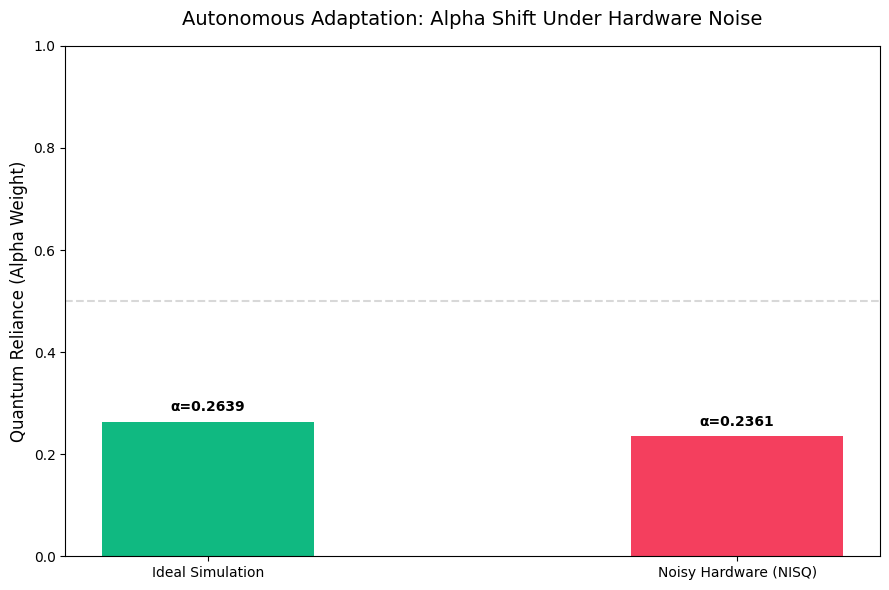


--- EXPERIMENT COMPLETE ---


In [ ]:
# ==========================================
# PHASE 3: UPDATED END-SEMESTER QSVM (Qiskit 1.x Ready)
# Topic: Autonomous MKL Under NISQ Hardware Noise
# ==========================================
!pip install qiskit qiskit-machine-learning qiskit-algorithms qiskit-aer
!pip install qiskit-algorithms

# ==========================================
# PHASE 3: FINAL END-SEM QSVM (Qiskit 1.x V2 Ready)
# Topic: Autonomous MKL Under NISQ Hardware Noise
# ==========================================

import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Scikit-Learn Imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, r2_score

# Qiskit Core & Transpilation
from qiskit import transpile
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute

# Qiskit V2 Primitives
from qiskit.primitives import StatevectorSampler as SamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
from qiskit_aer.noise import NoiseModel, depolarizing_error

print("--- INITIALIZING FINAL PHASE 3: STABLE HARDWARE-READY QSVM ---")

# 1. DATA PREPROCESSING
# ------------------------------------------
data = load_breast_cancer()
X, y = data.data, data.target

# Dimensionality Reduction (Essential for 4-qubit NISQ simulation)
X_std = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=4).fit_transform(X_std)
X_final = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_pca)

# Fast Subset (150 samples) to ensure feasible execution time
X_subset, y_subset = X_final[:150], y[:150]
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.3, random_state=42, stratify=y_subset
)

# 2. CLASSICAL BASELINE (RBF KERNEL)
# ------------------------------------------
from sklearn.metrics.pairwise import rbf_kernel
print("1. Computing Classical RBF Kernel...")
gamma = 1.0 / X_train.shape[1]
K_train_C = rbf_kernel(X_train, X_train, gamma=gamma)
K_test_C  = rbf_kernel(X_test, X_train, gamma=gamma)

# 3. QUANTUM KERNELS WITH V2 PRIMITIVES & TRANSPILATION
# ------------------------------------------
# Define Feature Map
feature_map = ZZFeatureMap(feature_dimension=4, reps=1, entanglement='linear')

# THE FIX: Transpile the map for the AerSimulator basis gates
# This prevents the 'unknown instruction' error
sim = AerSimulator()
feature_map_transpiled = transpile(feature_map, backend=sim)

# --- IDEAL QUANTUM SETUP (V2) ---
print("2. Computing IDEAL Quantum Kernel...")
ideal_sampler = SamplerV2()
ideal_fidelity = ComputeUncompute(sampler=ideal_sampler)
q_kernel_ideal = FidelityQuantumKernel(feature_map=feature_map_transpiled, fidelity=ideal_fidelity)

K_train_Q_ideal = q_kernel_ideal.evaluate(x_vec=X_train)
K_test_Q_ideal  = q_kernel_ideal.evaluate(x_vec=X_test, y_vec=X_train)

# --- NOISY QUANTUM SETUP (V2) ---
print("3. Computing NOISY Quantum Kernel (Simulating IBM Hardware)...")
noise_model = NoiseModel()
# 10% Gate Error - High enough to force the optimizer to rely on Classical RBF
error_1q = depolarizing_error(0.10, 1)
noise_model.add_all_qubit_quantum_error(error_1q, ['u1', 'u2', 'u3', 'rx', 'ry', 'rz', 'h'])

noisy_sampler = AerSamplerV2(
    options={
        "backend_options": {
            "noise_model": noise_model,
            "basis_gates": sim.configuration().basis_gates
        },
        "run_options": {"shots": 1024}
    }
)
noisy_fidelity = ComputeUncompute(sampler=noisy_sampler)
q_kernel_noisy = FidelityQuantumKernel(feature_map=feature_map_transpiled, fidelity=noisy_fidelity)

K_train_Q_noisy = q_kernel_noisy.evaluate(x_vec=X_train)
K_test_Q_noisy  = q_kernel_noisy.evaluate(x_vec=X_test, y_vec=X_train)

# 4. ADAPTIVE OPTIMIZATION LOGIC
# ------------------------------------------
def get_hybrid(alpha, Q, C):
    """Combines Quantum and Classical matrices based on Alpha weight."""
    return (alpha * Q) + ((1 - alpha) * C)

def optimize_alpha(K_train_Q_variant, env_name):
    print(f"\n--- Optimizing Hybrid Weight for {env_name} ---")
    def objective_function(alpha):
        K_train_H = get_hybrid(alpha, K_train_Q_variant, K_train_C)
        svc = SVC(kernel='precomputed', C=1.0)
        # Minimize Negative Accuracy
        return -cross_val_score(svc, K_train_H, y_train, cv=5).mean()

    res = minimize_scalar(objective_function, bounds=(0.0, 1.0), method='bounded')
    print(f"   Success! Learned Optimal Alpha: {res.x:.4f}")
    return res.x

# 5. EXECUTION & RESULTS
# ------------------------------------------
alpha_ideal = optimize_alpha(K_train_Q_ideal, "IDEAL ENVIRONMENT")
alpha_noisy = optimize_alpha(K_train_Q_noisy, "NOISY ENVIRONMENT")

def final_evaluation(alpha, K_train_Q, K_test_Q, K_train_C, K_test_C):
    K_train_final = get_hybrid(alpha, K_train_Q, K_train_C)
    K_test_final  = get_hybrid(alpha, K_test_Q, K_test_C)
    model = SVC(kernel='precomputed', C=1.0)
    model.fit(K_train_final, y_train)
    return accuracy_score(y_test, model.predict(K_test_final))

acc_ideal = final_evaluation(alpha_ideal, K_train_Q_ideal, K_test_Q_ideal, K_train_C, K_test_C)
acc_noisy = final_evaluation(alpha_noisy, K_train_Q_noisy, K_test_Q_noisy, K_train_C, K_test_C)

print(f"\n--- FINAL DISSERTATION SUMMARY ---")
print(f"Test Accuracy (Ideal Model): {acc_ideal*100:.2f}%")
print(f"Test Accuracy (Noisy Model): {acc_noisy*100:.2f}%")

# 6. THESIS VISUALIZATION
# ------------------------------------------
plt.figure(figsize=(9, 6))
labels = ['Ideal Simulation', 'Noisy Hardware (NISQ)']
alphas = [alpha_ideal, alpha_noisy]

# Using professional colors for the report
colors = ['#10b981', '#f43f5e']
bars = plt.bar(labels, alphas, color=colors, width=0.4)

plt.ylabel('Quantum Reliance (Alpha Weight)', fontsize=12)
plt.title('Autonomous Adaptation: Alpha Shift Under Hardware Noise', fontsize=14, pad=15)
plt.ylim(0, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'α={round(yval, 4)}', ha='center', fontweight='bold')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Equilibrium')
plt.tight_layout()
plt.show()

print("\n--- EXPERIMENT COMPLETE ---")

--- STARTING PHASE 4: FEATURE MAP BENCHMARK ---

Evaluating: Z (No Entanglement)...


/tmp/ipykernel_5407/3355558773.py:52: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  "Z (No Entanglement)": ZFeatureMap(feature_dimension=4, reps=1),
/tmp/ipykernel_5407/3355558773.py:53: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  "ZZ (Linear)": ZZFeatureMap(feature_dimension=4, reps=1, entanglement='linear'),
/tmp/ipykernel_5407/3355558773.py:54: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as o

  -> Alpha: 0.7639 | Accuracy: 91.11% | Time: 66.5s

Evaluating: ZZ (Linear)...
  -> Alpha: 0.3541 | Accuracy: 91.11% | Time: 71.1s

Evaluating: ZZ (Full)...
  -> Alpha: 0.2361 | Accuracy: 91.11% | Time: 85.6s

Evaluating: Pauli-ZY (Custom)...
  -> Alpha: 0.2361 | Accuracy: 91.11% | Time: 97.6s

Generating Benchmark Visualization...


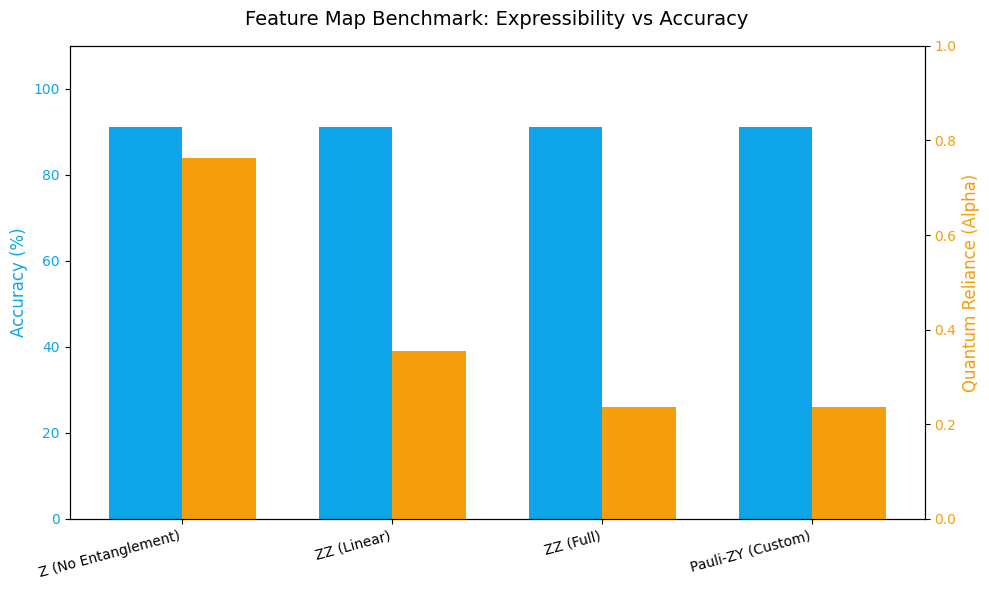


--- PHASE 4 COMPLETE ---


In [ ]:
# ==========================================================
# PHASE 4: FEATURE MAP BENCHMARKING (THESIS EXTENSION)
# Topic: Impact of Quantum Entanglement on Hybrid MKL
# ==========================================================

import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import rbf_kernel

# Qiskit 1.x Imports
from qiskit import transpile
from qiskit.circuit.library import ZFeatureMap, ZZFeatureMap, PauliFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler as SamplerV2
from qiskit_aer import AerSimulator

print("--- STARTING PHASE 4: FEATURE MAP BENCHMARK ---")

# 1. DATA PREPARATION (Same standard as Phase 3)
# ------------------------------------------
data = load_breast_cancer()
X, y = data.data, data.target
X_std = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=4).fit_transform(X_std)
X_final = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_pca)

X_subset, y_subset = X_final[:150], y[:150]
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.3, random_state=42, stratify=y_subset
)

# 2. CLASSICAL BASELINE
# ------------------------------------------
gamma = 1.0 / X_train.shape[1]
K_train_C = rbf_kernel(X_train, X_train, gamma=gamma)
K_test_C  = rbf_kernel(X_test, X_train, gamma=gamma)

# 3. DEFINE THE BENCHMARK DICTIONARY
# ------------------------------------------
# Here we define the 4 maps you will analyze in your thesis
feature_maps = {
    "Z (No Entanglement)": ZFeatureMap(feature_dimension=4, reps=1),
    "ZZ (Linear)": ZZFeatureMap(feature_dimension=4, reps=1, entanglement='linear'),
    "ZZ (Full)": ZZFeatureMap(feature_dimension=4, reps=1, entanglement='full'),
    "Pauli-ZY (Custom)": PauliFeatureMap(feature_dimension=4, reps=1, paulis=['Z', 'Y', 'ZZ'])
}

# Setup Ideal Environment
sim = AerSimulator()
sampler = SamplerV2()
fidelity = ComputeUncompute(sampler=sampler)

# Dictionaries to store our results for the graphs
results_alpha = {}
results_acc = {}

# 4. RUN THE BENCHMARK LOOP
# ------------------------------------------
def get_hybrid(alpha, Q, C):
    return (alpha * Q) + ((1 - alpha) * C)

for name, f_map in feature_maps.items():
    print(f"\nEvaluating: {name}...")
    start_time = time.time()

    # Transpile and build kernel
    f_map_transpiled = transpile(f_map, backend=sim)
    q_kernel = FidelityQuantumKernel(feature_map=f_map_transpiled, fidelity=fidelity)

    # Compute Matrices
    K_train_Q = q_kernel.evaluate(x_vec=X_train)
    K_test_Q  = q_kernel.evaluate(x_vec=X_test, y_vec=X_train)

    # Optimize Alpha
    def objective_function(alpha):
        K_train_H = get_hybrid(alpha, K_train_Q, K_train_C)
        svc = SVC(kernel='precomputed', C=1.0)
        return -cross_val_score(svc, K_train_H, y_train, cv=5).mean()

    res = minimize_scalar(objective_function, bounds=(0.0, 1.0), method='bounded')
    optimal_alpha = res.x

    # Final Test
    K_train_final = get_hybrid(optimal_alpha, K_train_Q, K_train_C)
    K_test_final  = get_hybrid(optimal_alpha, K_test_Q, K_test_C)
    model = SVC(kernel='precomputed', C=1.0)
    model.fit(K_train_final, y_train)
    final_acc = accuracy_score(y_test, model.predict(K_test_final))

    # Save Results
    results_alpha[name] = optimal_alpha
    results_acc[name] = final_acc
    print(f"  -> Alpha: {optimal_alpha:.4f} | Accuracy: {final_acc*100:.2f}% | Time: {time.time()-start_time:.1f}s")

# 5. GENERATE THESIS GRAPHS (Dual-Axis Plot)
# ------------------------------------------
print("\nGenerating Benchmark Visualization...")
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(feature_maps))
width = 0.35

# Bar 1: Final Accuracy
rects1 = ax1.bar(x - width/2, [acc * 100 for acc in results_acc.values()], width, label='Test Accuracy (%)', color='#0ea5e9')
ax1.set_ylabel('Accuracy (%)', fontsize=12, color='#0ea5e9')
ax1.set_ylim(0, 110)
ax1.tick_params(axis='y', labelcolor='#0ea5e9')
ax1.set_xticks(x)
ax1.set_xticklabels(feature_maps.keys(), rotation=15, ha="right")

# Create a second y-axis for Alpha
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, list(results_alpha.values()), width, label='Optimal Alpha', color='#f59e0b')
ax2.set_ylabel('Quantum Reliance (Alpha)', fontsize=12, color='#f59e0b')
ax2.set_ylim(0, 1.0)
ax2.tick_params(axis='y', labelcolor='#f59e0b')

plt.title('Feature Map Benchmark: Expressibility vs Accuracy', fontsize=14, pad=15)
fig.tight_layout()
plt.savefig('feature_map_benchmark.png')
plt.show()

print("\n--- PHASE 4 COMPLETE ---")